# Titanic Survival Analysis — Exploratory Data Analysis

**Dataset:** Kaggle Titanic `train.csv` &nbsp;|&nbsp; **Passengers:** 891 &nbsp;|&nbsp; **Survived:** 342 (38.4%)

On **April 15, 1912**, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of the ~2,200 people aboard.  
This notebook explores **who survived and why** using beginner-friendly charts and plain-English explanations.

---
### Table of Contents
1. Loading the Data
2. Data Overview & Missing Values
3. Overall Survival Rate
4. Survival by Passenger Class
5. Survival by Sex
6. Survival by Age
7. Survival by Fare
8. Survival by Family Size
9. Survival by Port of Embarkation



## Section 1 — Loading the Data

We import the essential libraries and load the CSV file into a pandas **DataFrame** (think of it as an Excel table in Python).

| Library | Purpose |
|---|---|
| `pandas` | Load and manipulate tabular data |
| `matplotlib` | Create basic charts and plots |


In [16]:
import pandas as pd
import matplotlib.pyplot as plt



SURVIVED_COLOR = 'blue'  
DIED_COLOR     = 'red'
ACCENT         = 'grey'

# Load data 
df = pd.read_csv('Titanic-Dataset.csv')

print('Dataset shape:' ,df.shape) 
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



## Section 2 — Data Overview & Missing Values

Before analysing data we must understand its **quality** — are there missing values?  
Missing values can distort results if not handled carefully.

### Column descriptions
| Column | Meaning | Type |
|---|---|---|
| `Survived` | 1 = survived, 0 = did not survive **(our target)** | Number |
| `Pclass` | Ticket class: 1=1st (wealthy), 2=2nd, 3=3rd (poor) | Number |
| `Sex` | male / female | Text |
| `Age` | Age in years | Number |
| `SibSp` | # of siblings / spouses aboard | Number |
| `Parch` | # of parents / children aboard | Number |
| `Fare` | Ticket price in British pounds (£) | Number |
| `Embarked` | Port: S=Southampton, C=Cherbourg, Q=Queenstown | Text |

In [17]:
# Check missing values 
missing = df.isnull().sum()


missing_pct = (missing / len(df) * 100).round(1)


missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df

,Missing Count,Missing %
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,177,19.9
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


In [18]:
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


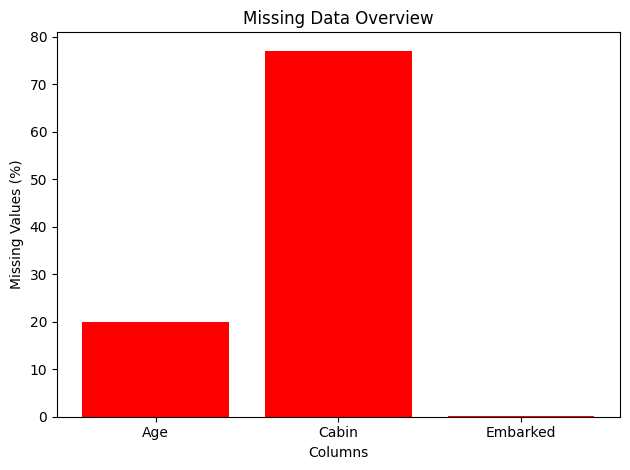

In [19]:
# count missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
# calculate percentage
pct = (missing_cols / len(df)) * 100
plt.bar(missing_cols.index, pct, color=DIED_COLOR)

# labels and title
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.title("Missing Data Overview")

plt.tight_layout()
plt.show()

In [20]:
# Fix missing values 
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')


##  Section 3 — Overall Survival Rate


In [21]:
# Overall survival numbers 
surv_counts = df['Survived'].value_counts().sort_index()
surv_rate   = df['Survived'].mean() * 100

print(f'Did NOT survive : {surv_counts[0]}  ({100 - surv_rate:.1f}%)')
print(f'Survived        : {surv_counts[1]}  ({surv_rate:.1f}%)')
print(f'Total passengers: {len(df)}')

Did NOT survive : 549  (61.6%)
Survived        : 342  (38.4%)
Total passengers: 891


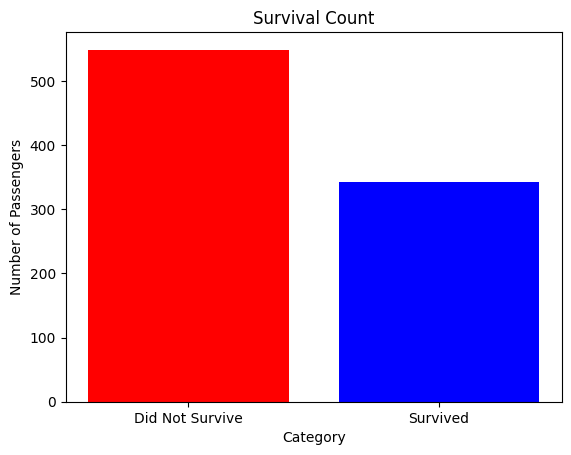

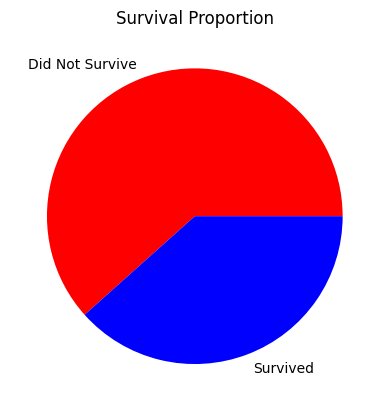

In [22]:

# labels
labels = ['Did Not Survive', 'Survived']

# Bar chart
plt.bar(labels, surv_counts, color=[DIED_COLOR, SURVIVED_COLOR])

plt.xlabel("Category")
plt.ylabel("Number of Passengers")
plt.title("Survival Count")


plt.show()


# Pie chart

plt.pie(surv_counts,labels=labels,colors=[DIED_COLOR, SURVIVED_COLOR])

plt.title("Survival Proportion")

plt.show()

> 💡 **Key Insight:** Only **38.4%** of passengers survived — roughly **2 in 3 people died**.  
> This is our baseline. We'll now explore *which groups* beat or fell below this rate.


## Section 4 — Survival by Passenger Class

The Titanic had three passenger classes, similar to economy/business/first class on a plane.  
- **1st class** — wealthy passengers, upper decks, closest to lifeboats  
- **2nd class** — middle class  
- **3rd class** — immigrants, lower decks, furthest from lifeboats

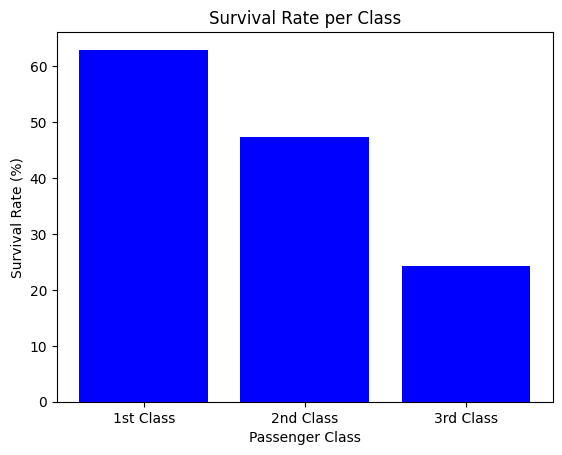

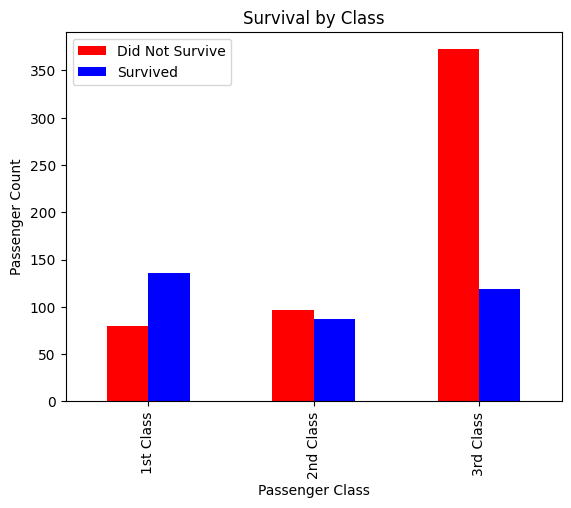

In [23]:
rate = df.groupby('Pclass')['Survived'].mean() * 100
labels = ['1st Class', '2nd Class', '3rd Class']


# 1
plt.bar(labels, rate.values, color=SURVIVED_COLOR)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate per Class")

plt.show()

# 2
counts = df.groupby(['Pclass', 'Survived']).size().unstack()
counts.plot(kind='bar',color=[DIED_COLOR, SURVIVED_COLOR])

plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.title("Survival by Class")

plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(['Did Not Survive', 'Survived'])

plt.show()


> 💡 **Key Insight:** 1st class had a **63% survival rate**, 2nd class **47%**, and 3rd class only **24%**.  
> A 1st class passenger was nearly **3× more likely to survive** than a 3rd class passenger.  
> Physical location (upper decks = closer to lifeboats) and social priority during evacuation both played a role.


##  Section 5 — Survival by Sex

The evacuation protocol was **"women and children first"**.  
Let's see if the data confirms this.

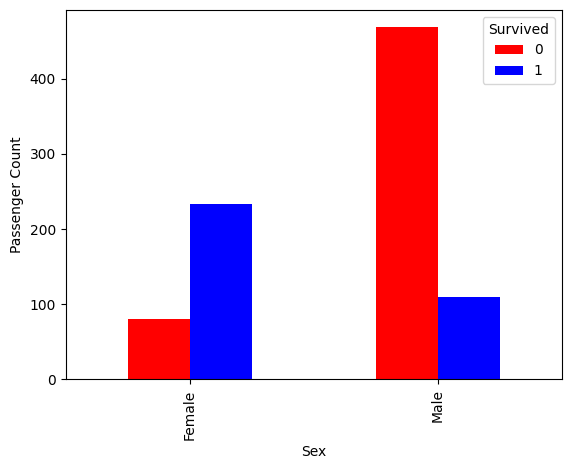

In [24]:
sex_rate  = df.groupby('Sex')['Survived'].mean() * 100
sex_count = df.groupby(['Sex', 'Survived']).size().unstack()


# count of survived vs not survived
counts = df.groupby(['Sex', 'Survived']).size().unstack()
counts.plot(kind='bar', color=[DIED_COLOR, SURVIVED_COLOR])

plt.xlabel("Sex")
plt.ylabel("Passenger Count")

plt.xticks([0, 1], ['Female', 'Male'])

plt.show()


> 💡 **Key Insight:** Women survived at **74.2%** vs men at only **18.9%**.  
> Sex is the **single strongest predictor** of survival in this dataset.  
> A woman was roughly **4× more likely to survive** than a man.


## Section 6 — Survival by Age

"Women and children first" — we've confirmed the women part. What about children?  
We'll look at age distributions and group passengers into age bands.

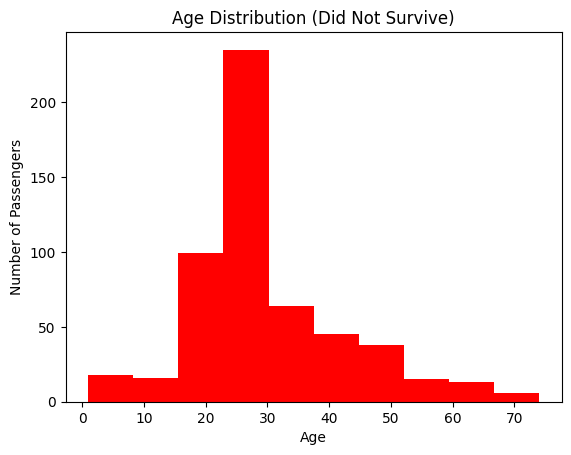

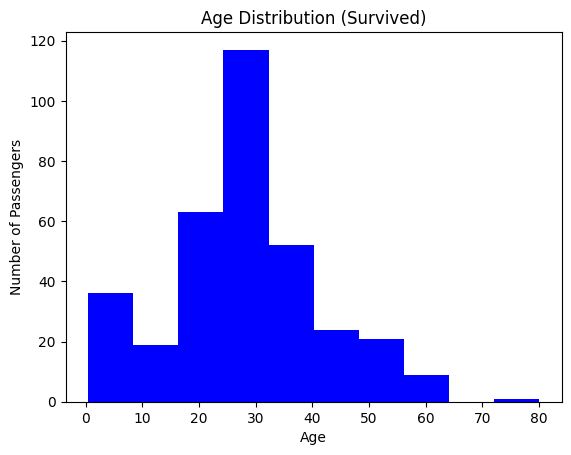

In [25]:
# Did Not Survive
plt.hist(df[df['Survived'] == 0]['Age'],color=DIED_COLOR)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution (Did Not Survive)")

plt.show()


# Survived
plt.hist(df[df['Survived'] == 1]['Age'],color=SURVIVED_COLOR)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution (Survived)")

plt.show()

> 💡 **Key Insight:**  
> - **Children (0–12)** had the highest survival rate — the protocol was followed  
> - **Seniors (60+)** had below-average survival — possibly less mobile  
> - 1st class passengers were generally **older** than 3rd class (wealthier = older demographic)  
> - Most passengers were **Young Adults (18–35)**, making them the largest group in both survivors and deaths


## Section 7 — Survival by Fare

Ticket prices ranged from £0 (crew / complimentary) to £512.  
We split fare into **4 equal groups (quartiles)** to compare survival rates.

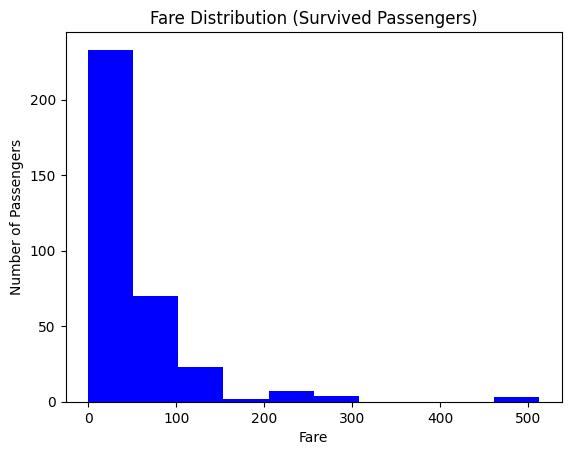

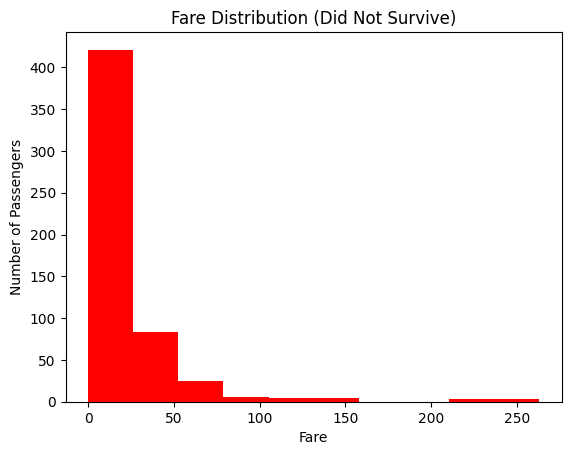

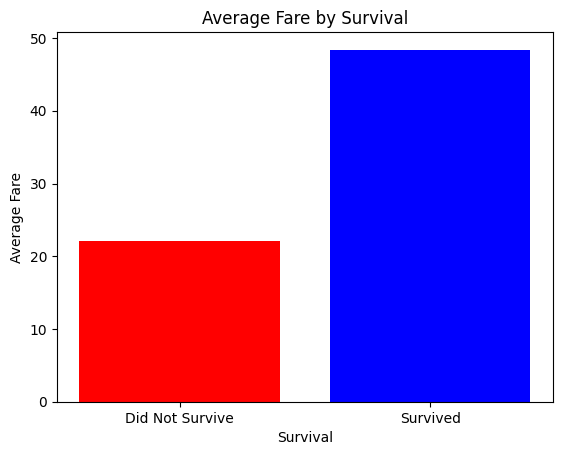

In [26]:
# Fare distribution

plt.hist(df[df['Survived'] == 1]['Fare'],color=SURVIVED_COLOR)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Fare Distribution (Survived Passengers)")
plt.show()


plt.hist(df[df['Survived'] == 0]['Fare'],color=DIED_COLOR)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Fare Distribution (Did Not Survive)")

plt.show()


# Survival rate
rate = df.groupby('Survived')['Fare'].mean()
labels = ['Did Not Survive', 'Survived']

plt.bar(labels, rate.values, color=[DIED_COLOR, SURVIVED_COLOR])

plt.xlabel("Survival")
plt.ylabel("Average Fare")
plt.title("Average Fare by Survival")

plt.show()

> 💡 **Key Insight:** There's a clear positive relationship — the more you paid, the better your odds.  
> The highest fare group survived at nearly **double** the rate of the lowest.  
> This is closely linked to passenger class: wealthier passengers paid more *and* were on upper decks.

<a id='8'></a>
## Section 8 — Survival by Family Size

We created `FamilySize = SibSp + Parch + 1` (includes self).  
A value of 1 means the passenger was **travelling alone**.

In [27]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

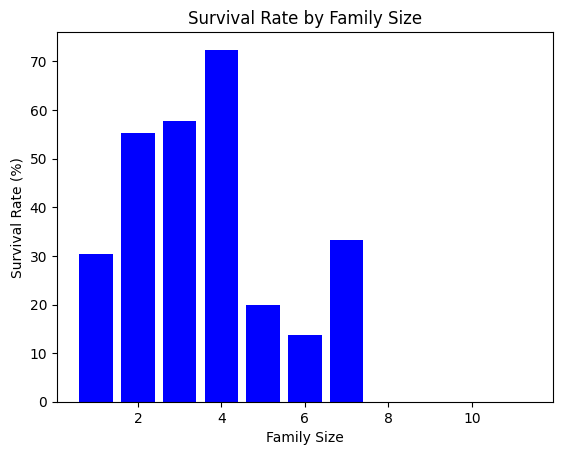

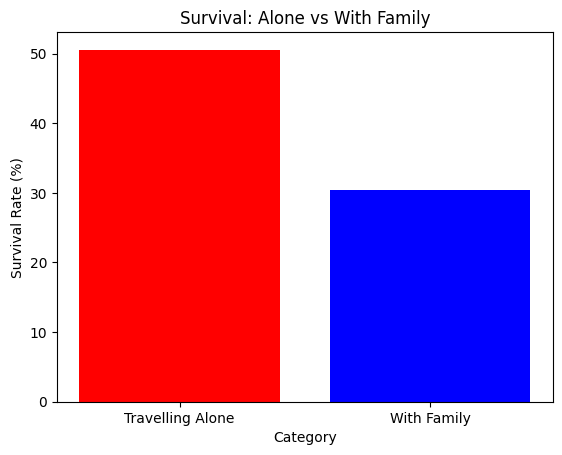

In [28]:
fam_rate  = df.groupby('FamilySize')['Survived'].mean() * 100
alone_rate = df.groupby('IsAlone')['Survived'].mean() * 100

# Survival rate by family size
plt.bar(fam_rate.index, fam_rate.values, color=SURVIVED_COLOR)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Family Size")
plt.show()

# ---- Alone vs With Family ----
labels = ['Travelling Alone', 'With Family']

plt.bar(labels, alone_rate.values, color=[DIED_COLOR, SURVIVED_COLOR])

plt.xlabel("Category")
plt.ylabel("Survival Rate (%)")
plt.title("Survival: Alone vs With Family")


plt.show()

> 💡 **Key Insight:**  
> - Small families of **2–4 people** had the **best survival odds** — members could help each other  
> - Solo travellers did *worse* than average — no one to help locate lifeboats  
> - Very large families (5+) also suffered — too hard to coordinate evacuation together  
> - Passengers with family survived at **50.6%** vs solo travellers at **30.4%**

## Section 9 — Survival by Port of Embarkation

The Titanic stopped at three ports before its fateful voyage:
- **S** — Southampton, England (majority boarded here)
- **C** — Cherbourg, France
- **Q** — Queenstown, Ireland (now Cobh)

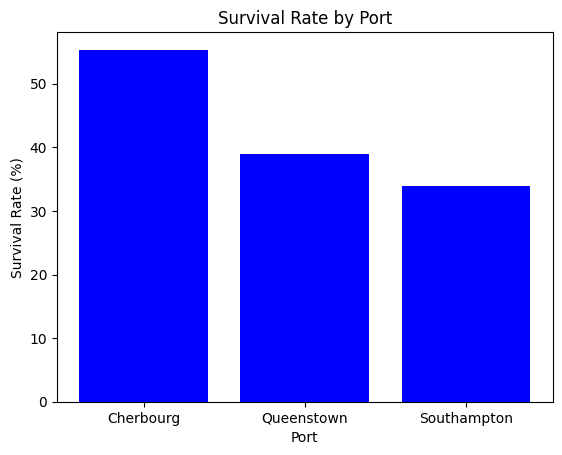

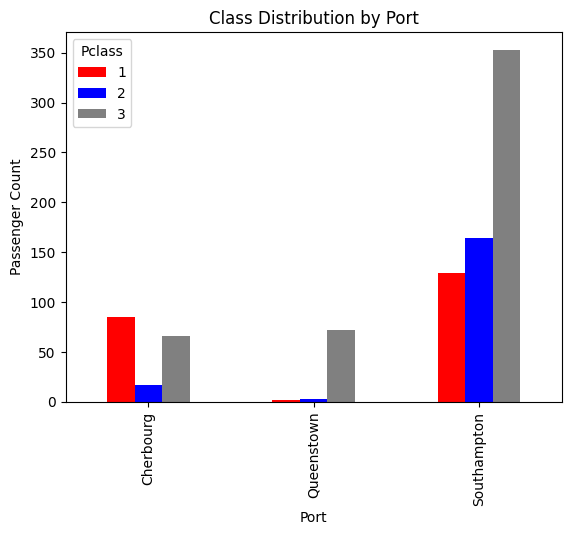

In [29]:
emb_rate  = df.groupby('Embarked')['Survived'].mean() * 100
emb_count = df.groupby('Embarked').size()
emb_class = df.groupby('Embarked')['Pclass'].mean()

labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}

# Survival rate by port
port_labels = [labels[p] for p in emb_rate.index]

plt.bar(port_labels, emb_rate.values, color=SURVIVED_COLOR)

plt.xlabel("Port")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Port")

plt.show()


# Passenger class mix 
emb_class_mix = df.groupby(['Embarked', 'Pclass']).size().unstack()
emb_class_mix.index = [labels[p] for p in emb_class_mix.index]
emb_class_mix.plot(kind='bar',color=[DIED_COLOR, SURVIVED_COLOR, ACCENT])

plt.xlabel("Port")
plt.ylabel("Passenger Count")
plt.title("Class Distribution by Port")

plt.show()

> 💡 **Key Insight:** Cherbourg passengers had the highest survival (~55%) — **not** because of the port itself,  
> but because many wealthy 1st class passengers boarded there.  
> Southampton had the lowest rate partly because it carried the most 3rd class passengers.  
> **Embarkation port is a proxy for class, not a direct cause.**